# <center>  Optimization and Dimensionality Reduction<center>
---
>**Course:** Data-Driven and Optimization
>
>**Topics:** Automatic Differentiation, Matrix Decompositions, and Feature Extraction  
---

## Task 1: Function Optimization and Gradients
Given the function:
$$f(x) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$$

*  Use `Matplotlib` to generate a 3D plot of the function.
* Generate a contour plot of $f$.
*  Determine the gradient of $f(x)$ using Autograd under `pyTorch`.
*  Determine the gradient at the point
  $$
    x = \begin{pmatrix} 1 \\ 1 \end{pmatrix}.
   $$
* Is $f$ a convex function?

---

## Task 2: Image Compression via SVD

Using the provided image of *Timbuktu* and the Python `OpenCV` library:
*  Convert the colored image into a gray-level image.
*  Read the grey-level values from 3a into a matrix.
*  Determine the SVD of the matrix in 3b.
*  Compress the image by keeping
  **25%**,
  **50%**, and
  **75%** of singular values, and compare the reconstructed results.

---

## Task 4: Principal Component Analysis (PCA)

Using the dataset `vehicle.csv`:
* Use a Jupyter notebook to upload the dataset.
* Perform the principal-component analysis of the data-set.
*  What are the principal-components?
---
---

# Task 1

Let 
$$f(x)=100(x_2-x_{1}^{2}) + (1-x_1)^2$$

In [ ]:
# Define f
def f(x1, x2):
    return 100 * (x2 - x1**2) + (1 - x1)**2


## 1.a) Plot 3D of this function using `Matplotlib`

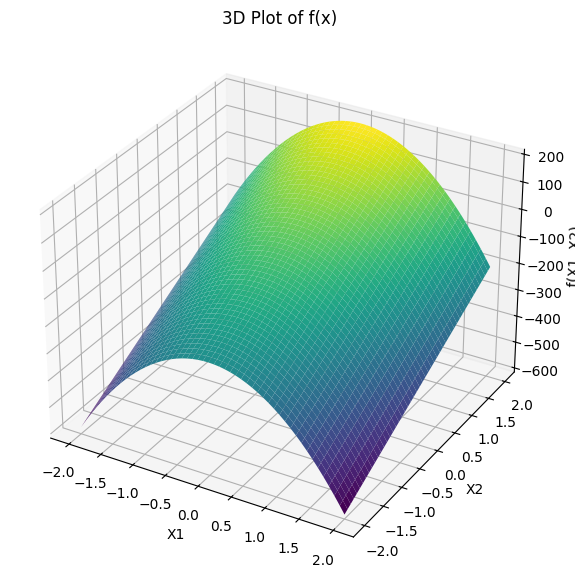

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a grid of x1 and x2 values
x1 = np.linspace(-2, 2, 400)
x2 = np.linspace(-2, 2, 400)
X1, X2 = np.meshgrid(x1, x2)

# Compute the function values
Z = f(X1, X2)

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z, cmap='viridis')

# Labels and title
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('f(X1, X2)')
ax.set_title('3D Plot of f(x)')

plt.show()


## 1.b) Contour plot of $f$

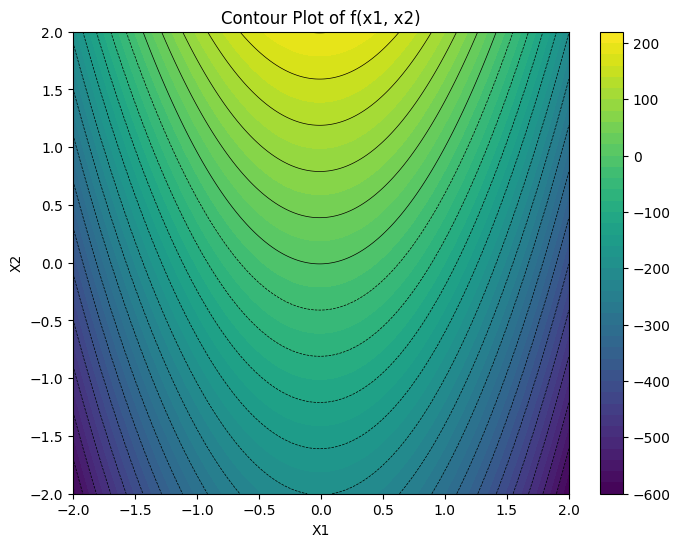

In [ ]:

# Plot the contour map
plt.figure(figsize=(8, 6))
contour = plt.contourf(X1, X2, Z, levels=50, cmap='viridis')
plt.colorbar(contour)  # Add color bar

# Add contour lines
plt.contour(X1, X2, Z, levels=20, colors='black', linewidths=0.5)

# Labels and title
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Contour Plot of f(x1, x2)')

plt.show()




## Determine the gradient of $f$ using `Autograd` under `pyTorch`.

In [ ]:
import torch

# Define input variables x1 and x2 with requires_grad=True to track gradients
x1 = torch.tensor(1.0, requires_grad=True)
x2 = torch.tensor(1.0, requires_grad=True)

# Compute the function value
z = f(x1, x2)

# Compute the gradients (backpropagation)
z.backward()

# Output the gradients of f with respect to x1 and x2
x1_grad = x1.grad
x2_grad = x2.grad

print(f"Gradient of f with respect to x1: {x1_grad}")
print(f"Gradient of f with respect to x2: {x2_grad}")


Gradient of f with respect to x1: -200.0
Gradient of f with respect to x2: 100.0


### Verification for this result

Wee know that the gradient of $f$ is defined as :
$$\nabla f(x)=\begin{bmatrix}
\frac{\partial f(x)}{\partial x_1}\\
\frac{\partial f(x)}{\partial x_2}
\end{bmatrix}$$
Then
$$\nabla f(x)=\begin{bmatrix}
-198x_1 -2\\
100
\end{bmatrix}$$
By evaluating this on $\begin{bmatrix}
1\\
1
\end{bmatrix}$, we obtain
$$\nabla f(x)=\begin{bmatrix}
-198(1) -2\\
100
\end{bmatrix}=\begin{bmatrix}
-200\\
100
\end{bmatrix}$$
It's equal to the result obtained by Autograd

## e) Convexity of $f$

To check the convexity a function $f$:
  - evaluate the Hessian $H(x)$
  - find all the eigenvalues of $H(x)$

If all eigenvalues are non-negative, then $f$ is convex. If all the
eigenvalues are positive, then $f$ is a strictly convex function.




In [ ]:
import torch
from torch.autograd.functional import hessian

def f(x):
    x1, x2 = x
    return 100 * (x2 - x1**2) + (1 - x1)**2  #

# Evaluate the hessian matrix at point (1,1)
x = torch.tensor([1.0, 1.0], requires_grad=True)

# Compute the Hessian matrix
hessian_matrix = hessian(f, x)

# Compute the eigenvalues of the Hessian matrix
eigenvalues, _ = torch.linalg.eig(hessian_matrix)

# Print results
print("Hessian Matrix:")
print(hessian_matrix)

print("\nEigenvalues of Hessian:")
print(eigenvalues.real)


Hessian Matrix:
tensor([[-198.,    0.],
        [   0.,    0.]])

Eigenvalues of Hessian:
tensor([-198.,    0.])


## Verification by hand

Let's compute $H(x)$
$$
H(x)=\nabla^2f(x)=\begin{bmatrix}
\frac{\partial^2f(x)}{\partial x_1^2} & \frac{\partial^2f(x)}{\partial x_1\partial x_2}\\
\frac{\partial^2f(x)}{\partial x_2\partial x_1} & \frac{\partial^2f(x)}{\partial x_2^2}
\end{bmatrix}
$$
Then
$$
H(x)=\begin{bmatrix}
-198 & 0\\
0 &0
\end{bmatrix}
$$
$H$ has two eigenvalue $\lambda_1=-198$ and $\lambda_2 = 0$. Since $\lambda_1$ is negative, it's means that the Hessian matrix of $f$ has a eigenvalue negative, then $f$ is non-convex.

# Task 2

## Original image

Original image


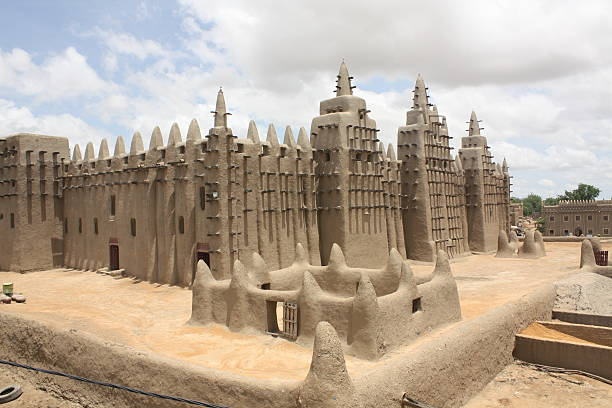

In [1]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image in color
image = cv2.imread("/content/Timbuktu.jpg")
print("Original image")
cv2_imshow(image)

## 2.a) Convert the colored image into a gray-level image.



grayscale image


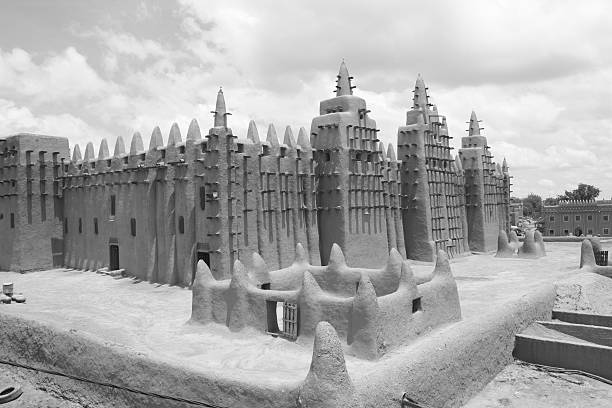

In [2]:

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Save and display the grayscale image
cv2.imwrite("timbuktu_gray.jpg", gray_image)
print("\n")
print("grayscale image")
cv2_imshow(gray_image)


## 2.b) Read the grey-level values from 3a into a matrix.

In [10]:
import numpy as np

# Convert grayscale image to a NumPy matrix
gray_matrix = np.array(gray_image)

# Display matrix dimensions
print("Matrix shape:", gray_matrix.shape)
print("Gray-Level Matrix:\n", gray_matrix)


Matrix shape: (408, 612)
Gray-Level Matrix:
 [[177 177 177 ... 243 243 243]
 [177 177 177 ... 243 243 243]
 [177 177 177 ... 244 244 244]
 ...
 [162 155 154 ... 197 199 199]
 [189 195 186 ... 194 197 197]
 [160 166 159 ... 192 195 194]]


## 2.c) Determine the SVD of  **gray_matrix**.

In [11]:
# Compute the SVD
U, S, Vt = np.linalg.svd(gray_matrix, full_matrices=False)

# Display the singular values
print("Singular values shape:", S.shape)
print("First 10 singular values:", S[:10])


Singular values shape: (408,)
First 10 singular values: [86686.93966562 10185.74717501  7762.58777285  4708.80312523
  4319.57532334  3676.11385079  3258.66191952  3097.71450866
  2944.0149043   2515.45613283]


## 2.d) Compression of the image by 
- 25%
-  50%
-  75%


Define a function compression

In [18]:
import matplotlib.pyplot as plt

# Function to compress image with a ratio given
def compress_image(U, S, Vt, keep_ratio):
    k = int(len(S) * (1-keep_ratio))  # Number of singular values to keep
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]

    # Reconstruct the image
    compressed = U_k @ np.diag(S_k) @ Vt_k
    return np.clip(compressed, 0, 255).astype(np.uint8)




# Plot of each image

## Original image in grayscale

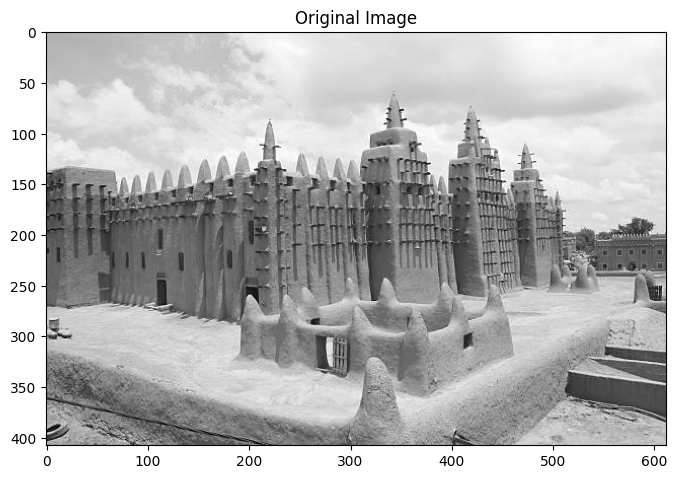

In [13]:
import matplotlib.pyplot as plt

# Display the original image
plt.figure(figsize=(8, 8))
plt.imshow(gray_image, cmap="gray")
plt.title("Original Image")
plt.show()


##   i) Compression 25%

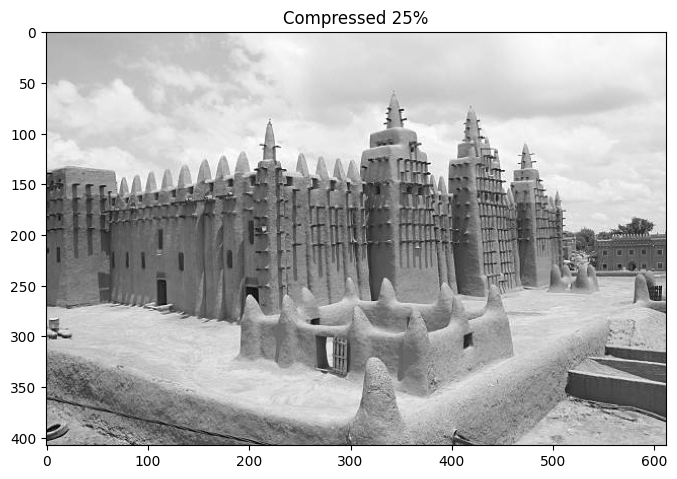

In [14]:
# Call the function compress image
compressed_images25 = compress_image(U, S, Vt, 0.25)

# Plot the image compressed
plt.figure(figsize=(8, 8))  # Create a new figure for each image
plt.imshow(compressed_images25, cmap="gray")
plt.title(f"Compressed 25%")
plt.show()

## ii) Compression 50%

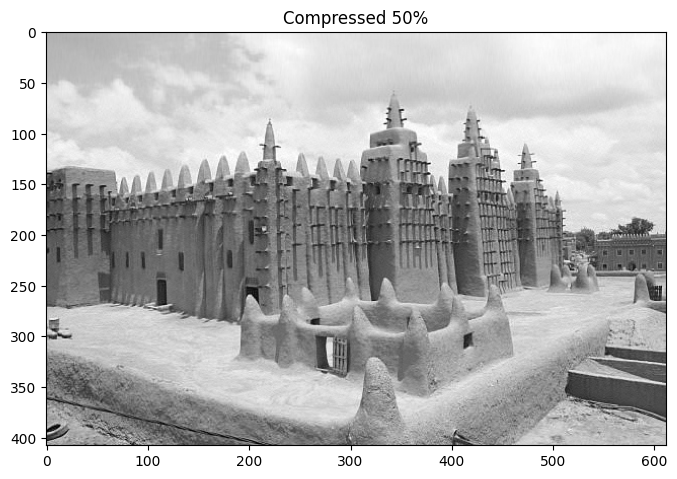

In [15]:
compressed_images50 = compress_image(U, S, Vt, 0.50)
plt.figure(figsize=(8, 8))  # Create a new figure for each image
plt.imshow(compressed_images50, cmap="gray")
plt.title(f"Compressed 50%")
plt.show()

## ii) Compression 75%

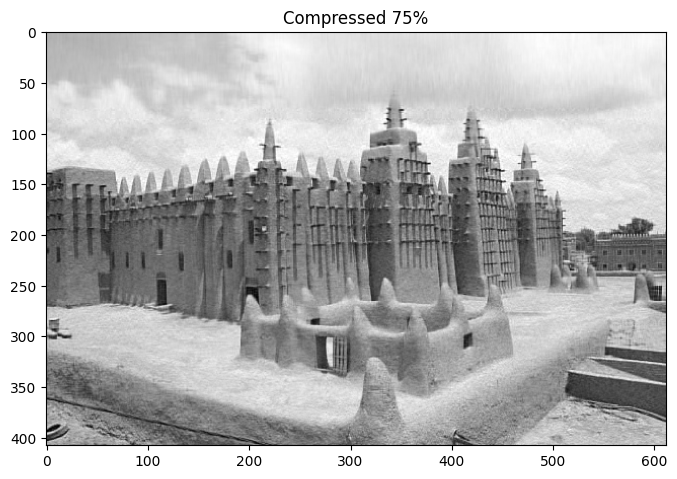

In [16]:
compressed_images75 = compress_image(U, S, Vt, 0.75)
plt.figure(figsize=(8, 8))  # Create a new figure for each image
plt.imshow(compressed_images75, cmap="gray")
plt.title(f"Compressed 75%")
plt.show()

## Analysis of Compression Effects

From the three compressed images at 75%, 50%, and 25%, we can observe the following:

**a)25\% Compression**
- Retains most details from the original image.
- Textures and edges remain sharp.
- Minimal loss of quality.

**b)50\% Compression**
- Small loss of fine details, particularly in sky and textures.
- Main structure is well-preserved.
- Slight blurring noticeable.

**c)75\% Compression**
- Noticeable loss of fine details.
- Sky appears blurred, and some structures lose clarity.
- Image appears smoother with minor artifacts.

## Conclusion
With higher compression (e.g: 75\%) , the image quality deteriorate (but require less storage). Medium compression (50\%) offers a balance between quality and size. Lower compression ratios (e.g:25\%) maintain better quality (but require more storage).

>In conclusion, as compression ratio increases , the image quality becomes bad but the storage requirement decreases.

## Further explanation
In the three compressed images above (75%, 50%, and 25%), the differences are not easily visible because the human eye is less sensitive to subtle variations in high-frequency details. The compression mainly affects fine details like textures and minor contrasts, which may not be obvious in the displayed images.


To better observe the effects of compression, we can further reduce the number of singular values used in the reconstruction. Let’s plot the compressed image at 95% to highlight the degradation in quality. At this level, we expect to see:

 - Significant blurring of the image, especially in high-detail regions.
 - Loss of structural sharpness, particularly around edges and fine textures.
 - Visible artifacts, making it clear how much information is discarded during compression.



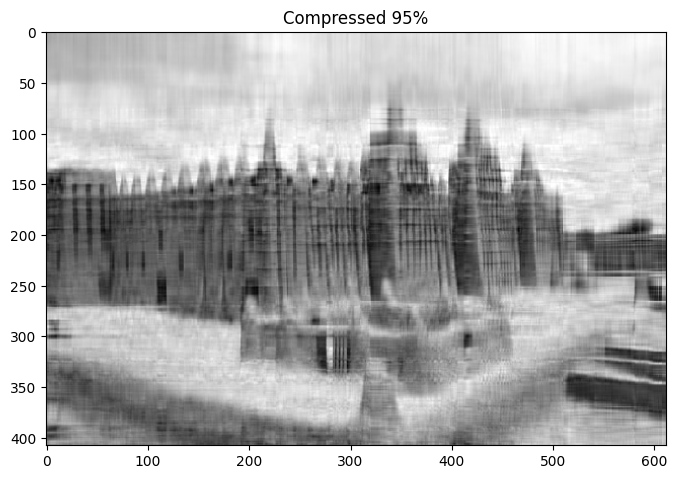

In [20]:
compressed_images10 = compress_image(U, S, Vt, 0.95)
plt.figure(figsize=(8, 8))  # Create a new figure for each image
plt.imshow(compressed_images10, cmap="gray")
plt.title(f"Compressed 95%")
plt.show()

# Task 3

In [21]:
import pandas as pd
# Load the dataset from Google Drive
file_path = "/content/vehicle.csv"
df = pd.read_csv(file_path)

# Display first few rows
display(df.head(4))

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van


In [22]:
len(df.columns)

19

Recuperate the names of last columns

In [23]:
last_columns  = df.columns[-1]
print(last_columns)

class


## Drop the last culumns

In [24]:
# Drop the last column
df_dropped = df.drop(df.columns[-1], axis=1)
df_dropped.head(4)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207


In [25]:
len(df_dropped.columns)

18

In [26]:
last_columns in df_dropped.columns

False

In [27]:
df_dropped.isna().sum()


,0
compactness,0
circularity,5
distance_circularity,4
radius_ratio,6
pr.axis_aspect_ratio,2
max.length_aspect_ratio,0
scatter_ratio,1
elongatedness,1
pr.axis_rectangularity,3
max.length_rectangularity,0


This result indicate the numbers of NaN values for each columns

## Replace the NaN values by mean because PCA not handle dataset contains NaN values.

In [28]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
# Fit the imputer and transform the DataFrame
df1 = pd.DataFrame(imputer.fit_transform(df_dropped), columns=df_dropped.columns)

df1.isna().sum()

,0
compactness,0
circularity,0
distance_circularity,0
radius_ratio,0
pr.axis_aspect_ratio,0
max.length_aspect_ratio,0
scatter_ratio,0
elongatedness,0
pr.axis_rectangularity,0
max.length_rectangularity,0


This result above show that the replacement working well.

## Standardize the data
PCA identifies principal components that capture the most variance in the data, but if features have different scales, those with larger values may dominate the analysis. **Standardization** transforms all features to have `mean = 0` and `standard deviation = 1`, ensuring they contribute equally to PCA and preventing bias towards high-magnitude features.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)

# Display the standardized data
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,0.160580,0.517302,0.056545,0.272965,1.310206,0.311542,-0.208038,0.136580,-0.225160,0.758332,-0.403077,-0.343028,0.285618,-0.327938,-0.074340,0.380665,-0.312193,0.183957
1,-0.325470,-0.624564,0.120112,-0.835442,-0.593962,0.094079,-0.599893,0.520853,-0.611739,-0.344578,-0.594546,-0.620879,-0.513719,-0.059987,0.537873,0.156589,0.013088,0.452977
2,1.254193,0.843549,1.518571,1.201630,0.548539,0.311542,1.148382,-1.144331,0.934576,0.689401,1.096764,1.108603,1.392391,0.073989,1.558230,-0.403603,-0.149552,0.049447
3,-0.082445,-0.624564,-0.007021,-0.296217,0.167705,0.094079,-0.750606,0.648945,-0.611739,-0.344578,-0.913661,-0.739958,-1.466773,-1.265769,-0.074340,-0.291565,1.639494,1.529056
4,-1.054545,-0.135193,-0.769817,1.081803,5.245485,9.444962,-0.599893,0.520853,-0.611739,-0.275646,1.671171,-0.649231,0.408593,7.308682,0.537873,-0.179527,-1.450677,-1.699181


## Perform PCA

In [30]:
# Perform PCA
pca = PCA()
pca.fit(df_scaled)

# Get the principal components
principal_components = pca.transform(df_scaled)

# Create a DataFrame for principal components
pc_df = pd.DataFrame(principal_components, columns=[f'PC{i+1}' for i in range(len(df_scaled.columns))])

# Display the first few rows of principal components
print(pc_df.head())

        PC1       PC2        PC3       PC4       PC5       PC6       PC7  \
0  0.332393  0.218638   1.001286 -0.177328  0.079106  0.754814 -0.902187   
1 -1.593741  0.420549  -0.369264 -0.233484  0.693397  0.519073  0.376234   
2  3.767535 -0.195041   0.088237 -1.203129  0.730907 -0.705377 -0.032642   
3 -1.740753  2.829579   0.109176 -0.377522 -0.363483  0.487863  0.468613   
4  0.555239 -4.757557  11.703588 -0.145068  3.257651  0.211649  2.671191   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14  \
0  0.383358 -0.868964 -0.088599  0.023302 -0.013586 -0.120285 -0.279619   
1 -0.247624  0.146542  0.096104  0.492591  0.272920 -0.041611 -0.076748   
2 -0.483439 -0.308888  0.469880  0.259449  0.144857 -0.055514 -0.065500   
3  0.022129 -0.029270 -0.458229  0.375358 -0.003531  0.214617 -0.171059   
4  0.446380  2.090488  0.348406  0.169747  0.108169 -0.174138 -0.179879   

       PC15      PC16      PC17      PC18  
0 -0.082246 -0.172969  0.012682  0.033157  
1 -0

In [31]:
#import numpy library
import numpy as np

#cumulative sum of explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

#list of variance ratio
var_explained = [0.15, 0.25, 0.35, 0.45, 0.50, 0.65, 0.75, 0.85, 0.95, 0.99]

#displays number of components principal needed for each variance ratio "in var_explained"
for var in var_explained:
      print(f"number of components explaining {var*100}% of variance is {np.where(explained_variance > var)[0][0]}")


number of components explaining 15.0% of variance is 0
number of components explaining 25.0% of variance is 0
number of components explaining 35.0% of variance is 0
number of components explaining 45.0% of variance is 0
number of components explaining 50.0% of variance is 0
number of components explaining 65.0% of variance is 1
number of components explaining 75.0% of variance is 2
number of components explaining 85.0% of variance is 3
number of components explaining 95.0% of variance is 6
number of components explaining 99.0% of variance is 10


**comment:** as we can see here, at least 10 principal components are needed for explaining 99% of variance of the data.

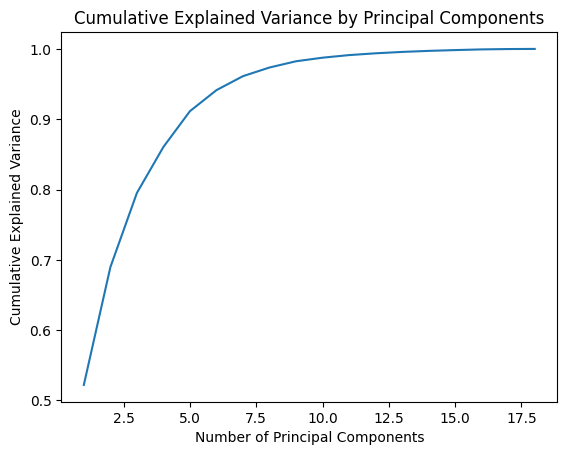

In [ ]:
#import matplotlib library
import matplotlib.pyplot as plt

# Plot the cumulative explained variance vs number of principal components
plt.plot(list(range(1, len(explained_variance) + 1)), explained_variance)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Principal Components')
plt.show()

**comment:** this plot confirms the comment above, as we can observe in the plot above, to explain > 99% of variance of the data, it needs at least 10 principal components.

In [32]:
#perform pca with 11 principal components
pca1 = PCA(n_components=11)
pca1.fit_transform(df_scaled)

#extract 11 best components and transfrom it to data frame and transpose the data
pca_best_comp = pd.DataFrame(pca1.components_, columns = df_scaled.columns).T

#names the columns of pca_comp to PC0 ... PC11
pca_best_comp.columns = [f'PC{i+1}' for i in range(len(pca_best_comp.columns))]

#add new column containing mean weight for each features
pca_best_comp["mean_weight"] = pca_best_comp.iloc[:].abs().mean(axis=1)

#sort the mean weight in descending order
pca_best_comp.sort_values("mean_weight", ascending=False)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,mean_weight
compactness,0.275259,0.127011,-0.119874,-0.078311,0.069306,-0.144650,0.453756,0.564714,-0.483554,0.261222,0.046450,0.238555
scaled_radius_of_gyration.1,-0.020918,-0.488542,0.286211,0.065653,0.145468,-0.241355,0.112980,0.339509,0.320573,-0.127135,0.419044,0.233399
max.length_aspect_ratio,0.097220,-0.010728,0.591800,-0.031320,0.213612,0.421019,0.501943,-0.161399,0.148444,0.117006,-0.262284,0.232434
scaled_radius_of_gyration,0.272003,-0.209280,-0.031369,-0.200102,-0.061617,0.134796,-0.374606,0.110225,0.243567,0.685493,-0.160353,0.225765
skewness_about.1,0.058333,0.124153,-0.075488,0.665740,0.599544,0.190919,-0.284844,0.209376,0.009383,0.035247,-0.032140,0.207742
distance_circularity,0.304556,0.072686,-0.056006,0.070796,0.040724,0.138488,0.072799,-0.436047,-0.167574,0.208495,0.705943,0.206738
max.length_rectangularity,0.282790,-0.116183,-0.016999,-0.187988,-0.060545,0.461743,-0.106082,0.250220,-0.063579,-0.469168,0.144877,0.196379
skewness_about,0.041332,0.054921,-0.115694,-0.605093,0.728920,-0.203564,-0.080046,-0.156326,0.022129,-0.098477,-0.012724,0.192657
pr.axis_aspect_ratio,0.080494,0.122159,0.642046,-0.032858,-0.040594,-0.237891,-0.397139,0.070004,-0.278147,-0.106402,0.039846,0.186144
skewness_about.2,0.030156,0.540948,0.008689,-0.105618,-0.100587,-0.156533,0.018829,0.304038,0.516504,-0.021143,0.122349,0.175036


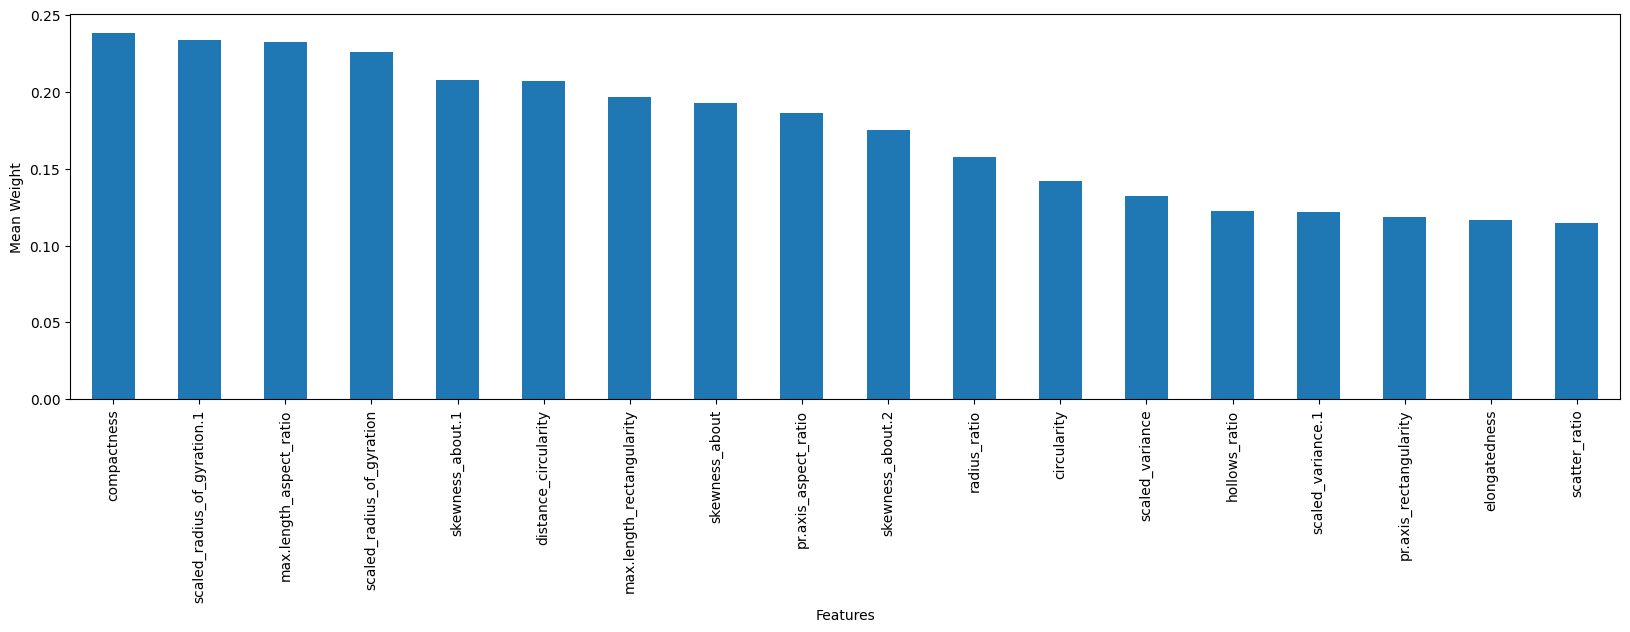

In [33]:
#plot of features according to its importance based on mean_weight values
plt.figure(figsize=(20, 5))
pca_best_comp.mean_weight.sort_values(ascending=False).plot(kind="bar")
plt.xlabel("Features")
plt.ylabel("Mean Weight")
plt.show()